# Trading Strategy Project - Developing Alpha Signals from Alternative Data

We define $r_{i,t+1}$ as the future return of asset $i$. Let $X_{i,t}$ be an alpha signal. We say that such a signal is significant if 
$$\mathbb E[r_{i,t+1}] \neq \mathbb E[r_{i,t+1} ~|~ X_{i,t}].$$

Our goal is to generate significant alpha signals from alternative data, such as reddit posts, foot traffic, X, etc.

Before we attempt to generate alpha signals from alternative data, we will try simple trading strategies simply based on daily returns, moving averages, and volatility. We will use models such as RandomForestRegressor and XGBoost, as well as a Cross-Sectional Ranking Strategy. 

In [115]:
import pandas as pd
import numpy as np
import yfinance as yf
import requests
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from yahoo_fin import news
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


In [99]:
df = yf.download("AAPL", start="2025-01-02", end="2026-05-11")

close = df["Close"].squeeze()
df["returns"] = close.pct_change()
df["ma_20"] = close.rolling(20).mean()
df["ma_gap"] = close / df["ma_20"] - 1
df["vol_20"] = df["returns"].rolling(20).std()
df["target"] = df["returns"].shift(-1)

df = df.dropna()
df.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,returns,ma_20,ma_gap,vol_20,target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,
2026-05-01,280.140015,287.220001,278.369995,278.859985,79915400,0.032394,266.359000,0.051738,0.016524,-0.011816
2026-05-04,276.829987,280.630005,274.859985,279.660004,46668400,-0.011816,267.257500,0.035817,0.016836,0.026551
2026-05-05,284.179993,284.570007,276.500000,276.929993,49311700,0.026551,268.791499,0.057251,0.016575,0.011718
2026-05-06,287.510010,288.029999,281.070007,281.920013,58336100,0.011718,270.222000,0.063977,0.016240,-0.000243
2026-05-07,287.440002,292.130005,285.779999,289.269989,45224300,-0.000243,271.569501,0.058440,0.016287,0.020456


<Axes: title={'center': 'AAPL Price'}, xlabel='Date'>

<Figure size 640x480 with 0 Axes>

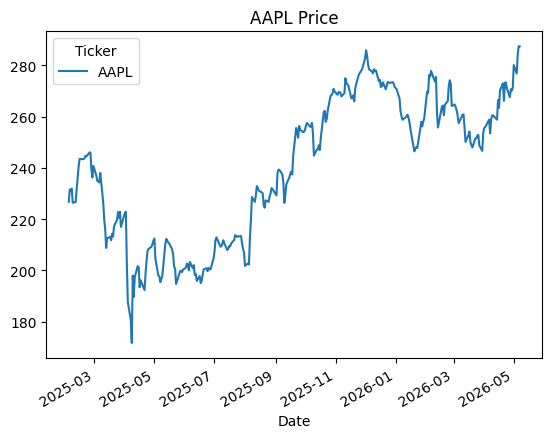

In [100]:
plt.figure()
df["Close"].plot(title="AAPL Price")

<Axes: title={'center': 'AAPL Daily Returns'}, xlabel='Date'>

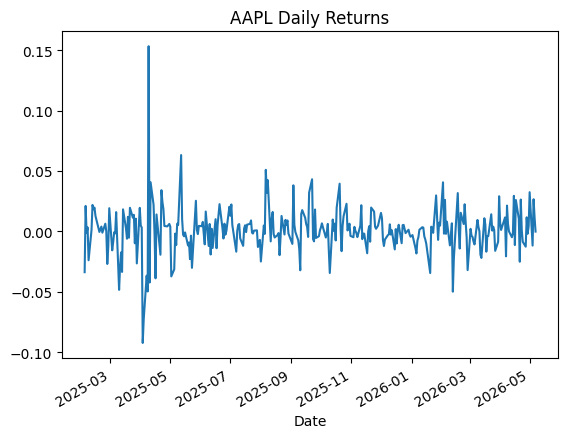

In [101]:
plt.figure()
df["returns"].plot(title="AAPL Daily Returns")

Let's come up with a way to predict tomorrow's stock price.

In [102]:
features = ["returns", "ma_gap", "vol_20", "ma_20"]

X = df[features]
y = df["target"]

split = int(0.8 * len(df))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

corr = np.corrcoef(y_pred, y_test)[0,1]
print(corr)

0.010094547410812163


No correlation, we need to come up with a new way to generate signals.

In [103]:
tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]

data = yf.download(tickers, start="2025-01-01")["Close"]

returns = data.pct_change()
momentum_5 = data.pct_change(5)
momentum_20 = data.pct_change(20)
vol_20 = returns.rolling(20).std()
ma_20 = data.rolling(20).mean()
ma_gap = data / ma_20 - 1
target = returns.shift(-1)

df = []

for ticker in tickers:
    tmp = pd.DataFrame({
        "return": returns[ticker],
        "mom_5": momentum_5[ticker],
        "mom_20": momentum_20[ticker],
        "vol_20": vol_20[ticker],
        "ma_gap": ma_gap[ticker],
        "target": target[ticker]
    })

    tmp["ticker"] = ticker
    df.append(tmp)

df = pd.concat(df)
df = df.dropna()

df[df["ticker"] == "MSFT"].head()

[*********************100%***********************]  5 of 5 completed


,return,mom_5,mom_20,vol_20,ma_gap,target,ticker
Date,,,,,,,
2025-02-03,-0.009974,-0.054400,-0.018300,0.021148,-0.039950,0.003529,MSFT
2025-02-04,0.003529,-0.077885,-0.025936,0.020983,-0.035325,0.002231,MSFT
2025-02-05,0.002231,-0.065652,-0.034031,0.020820,-0.031524,0.006122,MSFT
2025-02-06,0.006122,0.002000,-0.015508,0.020709,-0.024847,-0.014598,MSFT
2025-02-07,-0.014598,-0.012793,-0.034883,0.020891,-0.037410,0.006028,MSFT


# Random Forest Regression Strategy (Baseline Alpha Model)

## Overview
This strategy attempts to predict **next-day stock returns directly** using simple technical indicators. It is a supervised regression problem:

$$
X_{i,t} \rightarrow r_{i,t+1}
$$

Each stock is treated independently, and predictions are used to generate trading signals.

---

## Features (Inputs)

We use standard technical indicators:

- **return**: daily return \( r_{i,t} \)
- **mom_5**: 5-day momentum (short-term trend)
- **mom_20**: 20-day momentum (medium-term trend)
- **vol_20**: 20-day rolling volatility (risk proxy)
- **ma_gap**: deviation from moving average (mean reversion signal)

---

## Target

- **target = next-day return**
\[
r_{i,t+1}
\]

---

## Model

We use:
- Random Forest Regressor

This model captures nonlinear interactions between features.

---

## Trading Rule

- If predicted return > 0 → go **long**
- If predicted return < 0 → go **short**

---

## Strategy Return

$$
R_t = \text{signal}_t \cdot r_{t+1}
$$

---

## Intuition

Buy stocks the model expects to go up tomorrow and short those expected to go down

---

## Limitation

- No cross-sectional comparison between stocks
- Highly noisy at daily frequency
- Weak predictive signal in isolation

Prediction correlation: 0.17375890318571682
MSE: 0.0006010995772169308


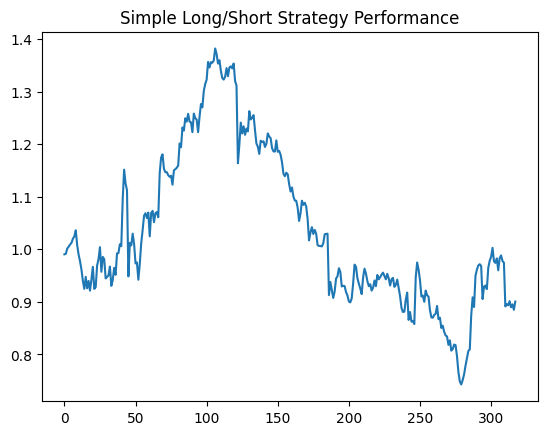

In [104]:
features = ["return", "mom_5", "mom_20", "vol_20", "ma_gap"]

X = df[features]
y = df["target"]

# ----------------------------
# 1. TIME SPLIT
# ----------------------------

split = int(0.8 * len(df))

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# ----------------------------
# 2. MODEL
# ----------------------------

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

# ----------------------------
# 3. PREDICTIONS
# ----------------------------

y_pred = model.predict(X_test)

# ----------------------------
# 4. EVALUATION (SIGNAL QUALITY)
# ----------------------------

corr = np.corrcoef(y_pred, y_test)[0, 1]
print("Prediction correlation:", corr)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

# ----------------------------
# 5. SIMPLE TRADING STRATEGY
# ----------------------------

signal = np.where(y_pred > 0, 1, -1)
strategy_returns = signal * y_test.values

cumulative = np.cumprod(1 + strategy_returns)

plt.plot(cumulative)
plt.title("Simple Long/Short Strategy Performance")
plt.show()

# XGBoost Regression Strategy (Nonlinear Alpha Model)

## Overview
This strategy improves upon the baseline by using a more powerful nonlinear model to predict next-day returns:

$$
X_{i,t} \rightarrow r_{i,t+1}
$$

It captures nonlinear relationships and interactions between features.

---

## Features

Same as baseline:
- return
- mom_5
- mom_20
- vol_20
- ma_gap

---

## Model

We use:

:contentReference[oaicite:0]{index=0}

Key idea:
- Sequential tree boosting
- Each tree corrects errors of previous ones
- Captures nonlinear patterns in financial data

---

## Trading Rule

- If predicted return > 0 → long
- If predicted return < 0 → short

---

## Intuition

Instead of simple averages, the model learns complex conditional rules like:
- momentum works only when volatility is low
- mean reversion depends on regime”

---

## Advantage over Random Forest

- Better handling of weak signals
- Captures nonlinear structure
- Typically more stable predictions

---

## Limitation

- Still predicts absolute returns
- Does not exploit cross-sectional relationships

[*********************100%***********************]  5 of 5 completed


Prediction correlation: 0.006703088121039261


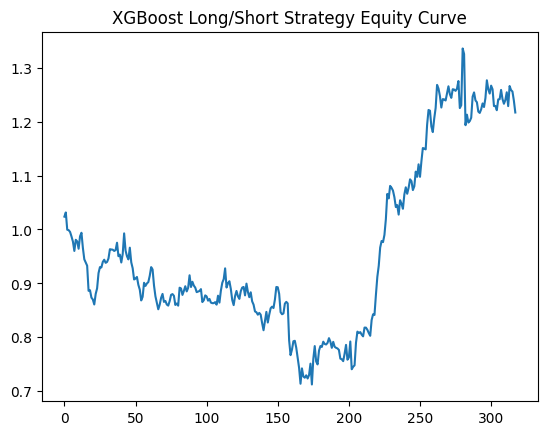

In [105]:
# ----------------------------
# 1. DATA
# ----------------------------

tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]

data = yf.download(tickers, start="2025-01-01")["Close"]

returns = data.pct_change()
momentum_5 = data.pct_change(5)
momentum_20 = data.pct_change(20)
vol_20 = returns.rolling(20).std()
ma_20 = data.rolling(20).mean()
ma_gap = data / ma_20 - 1

# predict next-day return
target = returns.shift(-1)

# ----------------------------
# 2. BUILD PANEL DATASET
# ----------------------------

df_list = []

for t in tickers:
    tmp = pd.DataFrame({
        "return": returns[t],
        "mom_5": momentum_5[t],
        "mom_20": momentum_20[t],
        "vol_20": vol_20[t],
        "ma_gap": ma_gap[t],
        "target": target[t]
    })
    
    tmp["ticker"] = t
    df_list.append(tmp)

df = pd.concat(df_list).dropna()
df = df.sort_index()

# ----------------------------
# 3. FEATURES / TARGET
# ----------------------------

features = ["return", "mom_5", "mom_20", "vol_20", "ma_gap"]

X = df[features]
y = df["target"]

# ----------------------------
# 4. TIME SPLIT
# ----------------------------

split = int(0.8 * len(df))

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# ----------------------------
# 5. XGBOOST MODEL
# ----------------------------

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# ----------------------------
# 6. PREDICTIONS
# ----------------------------

y_pred = model.predict(X_test)

# ----------------------------
# 7. EVALUATION
# ----------------------------

corr = np.corrcoef(y_pred, y_test)[0, 1]
print("Prediction correlation:", corr)

# ----------------------------
# 8. TRADING STRATEGY
# ----------------------------

signal = np.where(y_pred > 0, 1, -1)

strategy_returns = signal * y_test.values

# cumulative performance
cumulative = np.cumprod(1 + strategy_returns)

# ----------------------------
# 9. PLOT EQUITY CURVE
# ----------------------------

plt.figure()
plt.plot(cumulative)
plt.title("XGBoost Long/Short Strategy Equity Curve")
plt.show()

# Cross-Sectional Ranking Strategy 

## Overview
Instead of predicting absolute returns, this strategy predicts **relative performance across stocks** each day.

The model is used to rank stocks cross-sectionally:

$$
f(X_{i,t}) \rightarrow \text{ranking of stocks at time } t
$$

---

## Features

Same feature set:
- return
- mom_5
- mom_20
- vol_20
- ma_gap

---

## Key Idea

Each day:
- We compare all stocks to each other
- We do NOT care about exact return values
- We care about **who will outperform vs underperform**

---

## Trading Rule

Each day:

- 🟢 Top-ranked stocks → LONG
- 🔴 Bottom-ranked stocks → SHORT
- 🟡 Middle stocks → ignored

---

## Strategy Return

Portfolio return is:

$$
R_t = \text{average return of longs} - \text{average return of shorts}
$$

---

## Intuition

The model is not predicting returns — it is predicting rankings.

This aligns with how real hedge funds build equity long/short strategies.

---

## Why this works better

- Reduces noise from absolute return prediction
- Exploits cross-sectional inefficiencies
- More stable than single-stock prediction

---

## Limitation

- Depends heavily on feature quality
- Requires strong ranking signal (not just prediction accuracy)

[*********************100%***********************]  10 of 10 completed


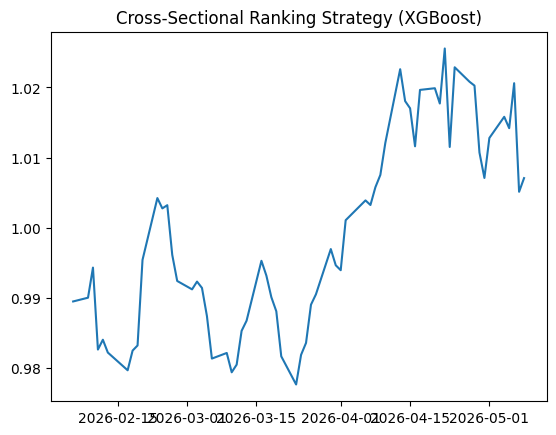

Prediction correlation: -0.016407643273027094


In [106]:
# ----------------------------
# 1. DATA
# ----------------------------

tickers = ["AMD", "MSFT", "AMZN", "GOOGL", "META", "NVDA", "COST", "TSLA", "JPM", "LLY"]

data = yf.download(tickers, start="2025-01-01")["Close"]

returns = data.pct_change()
momentum_5 = data.pct_change(5)
momentum_20 = data.pct_change(20)
vol_20 = returns.rolling(20).std()
ma_20 = data.rolling(20).mean()
ma_gap = data / ma_20 - 1

target = returns.shift(-1)

# ----------------------------
# 2. BUILD PANEL DATASET
# ----------------------------

df_list = []

for t in tickers:
    tmp = pd.DataFrame({
        "return": returns[t],
        "mom_5": momentum_5[t],
        "mom_20": momentum_20[t],
        "vol_20": vol_20[t],
        "ma_gap": ma_gap[t],
        "target": target[t]
    })
    tmp["ticker"] = t
    df_list.append(tmp)

df = pd.concat(df_list).dropna()
df = df.sort_index()

features = ["return", "mom_5", "mom_20", "vol_20", "ma_gap"]

# ----------------------------
# 3. TIME SPLIT
# ----------------------------

split = int(0.8 * len(df))

train = df.iloc[:split]
test = df.iloc[split:]

X_train, y_train = train[features], train["target"]
X_test = test[features]
y_test = test["target"]

# ----------------------------
# 4. MODEL (XGBOOST)
# ----------------------------

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# ----------------------------
# 5. PREDICTIONS
# ----------------------------

test = test.copy()
test["pred"] = model.predict(X_test)

# ----------------------------
# 6. RANKING STRATEGY
# ----------------------------

# cross-sectional ranking each day
test["rank"] = test.groupby(test.index)["pred"].rank()

# normalize ranks into signals
test["signal"] = test.groupby(test.index)["rank"].transform(
    lambda x: (x - x.mean()) / x.std()
)

# ----------------------------
# 7. STRATEGY RETURNS
# ----------------------------

test["strategy_return"] = test["signal"] * test["target"]

# aggregate across stocks per day
daily_returns = test.groupby(test.index)["strategy_return"].mean()

# cumulative performance
equity_curve = (1 + daily_returns).cumprod()

# ----------------------------
# 8. PLOT
# ----------------------------

plt.figure()
plt.plot(equity_curve)
plt.title("Cross-Sectional Ranking Strategy (XGBoost)")
plt.show()

# ----------------------------
# 9. METRIC: CORRELATION
# ----------------------------

corr = np.corrcoef(test["pred"], test["target"])[0, 1]
print("Prediction correlation:", corr)

In [107]:
trend_df.to_csv("google_trends_cache.csv", index=False)

#  Google Trends + XGBoost Alpha Strategy (Explanation)

## Objective
The goal of this strategy is to predict short-term stock returns using a combination of:
- traditional market-based features (momentum, volatility, trend)
- alternative data (Google search interest as a proxy for investor attention)

We model the relationship:
$$
X_{i,t} \rightarrow r_{i,t+1}
$$
where features at time *t* are used to predict next-day returns.

---

## Features Used

For each stock and each day, we construct:

### 1. Price-based signals
- **return**: daily percentage change
- **mom_5**: 5-day momentum (short-term trend)
- **mom_20**: 20-day momentum (medium-term trend)
- **vol_20**: 20-day rolling volatility (risk / uncertainty proxy)
- **ma_gap**: deviation from 20-day moving average (mean reversion signal)

### 2. Alternative data signal (Google Trends)
- **trend**: normalized search interest for the ticker symbol

This captures **investor attention**, which often precedes price movement due to:
- retail trading activity
- news-driven hype
- information diffusion delays

---

## Intuition Behind the Strategy

The core hypothesis is:

> Markets are partially driven by attention, not just fundamentals.

When search interest in a stock increases:
- more investors are likely researching or reacting to news
- trading volume often increases
- short-term price pressure can emerge

The model learns nonlinear interactions between:
- price momentum (technical trend continuation)
- volatility (risk regime)
- attention spikes (Google Trends)

---

## Model (Machine Learning Layer)

We use **XGBoost regression**, which:
- captures nonlinear relationships
- handles feature interactions automatically
- is robust to noisy financial data

The model outputs:
$$
\hat{r}_{t+1}
$$
a prediction of next-day return.

---

## Trading Strategy (How We Invest)

At each time step:

### Step 1: Predict returns
- If predicted return > 0 → bullish view
- If predicted return < 0 → bearish view

### Step 2: Convert predictions into positions
- **Long (+1)** if model predicts positive return
- **Short (-1)** if model predicts negative return

### Step 3: Compute strategy return
\[
\text{strategy return}_t = \text{position}_t \times r_{t+1}
\]

### Step 4: Compound returns
We simulate portfolio growth over time:
$$
\text{equity}_t = \prod (1 + \text{strategy return}_t)
$$

---

## Evaluation Metrics

We evaluate performance using:

### 1. Prediction correlation
Measures alignment between:
- predicted returns
- actual returns

Higher = better directional accuracy.

### 2. Equity curve
Shows how a $1 initial investment grows over time using the strategy.

---

## Important Assumptions

- No transaction costs included
- No slippage or liquidity constraints
- Equal weight across assets
- Fully invested long/short exposure each period

---

## Key Insight

Even weak signals (like Google search interest) can improve prediction when combined with:
- momentum
- volatility structure
- nonlinear ML models

The edge in this strategy comes from **aggregating weak signals into a stronger predictive model** rather than relying on any single indicator.

Cache updated. Total rows: 576


[*********************100%***********************]  8 of 8 completed


[-3.3265669e-04 -5.6127342e-03 -5.6260694e-03 -7.8413375e-03
  6.5676812e-03  2.0149746e-03  1.4645740e-02  1.1123023e-02
 -2.1970426e-04  3.7260598e-03  9.2102448e-03  1.5585604e-03
  1.1781040e-02 -6.4583152e-04 -1.7933849e-02  7.0032780e-03
 -6.2952414e-03  4.1179007e-04  8.0546262e-03 -7.5725927e-03
  2.2588237e-03 -2.3114020e-03 -2.3002291e-02  1.5397554e-02
  2.5851026e-03  6.9547924e-03  5.0836070e-03 -2.8021123e-02
 -6.2075369e-03  1.6413322e-03  4.9892375e-03 -1.0845823e-03
  9.3862135e-03  1.3099635e-02 -4.1051470e-03 -8.9791678e-03
 -4.4524632e-03  9.7646359e-03  1.0647258e-02  2.3083089e-02
  1.7912375e-02  1.8846152e-02 -7.3294382e-04  1.5923413e-02
  1.4329895e-04 -1.1281403e-02  1.3616193e-02 -1.1169110e-02
 -9.5330179e-03 -1.1768158e-03 -4.0938314e-03 -1.4078847e-02
 -1.3541624e-02 -1.1762589e-02 -1.4218879e-02 -4.5321146e-03
  5.6655137e-03 -6.1967191e-03 -6.9186296e-03 -1.2195985e-02
  8.7537318e-03  2.4339082e-02  4.4585243e-03 -6.4568701e-03
  1.4117468e-03  1.91204

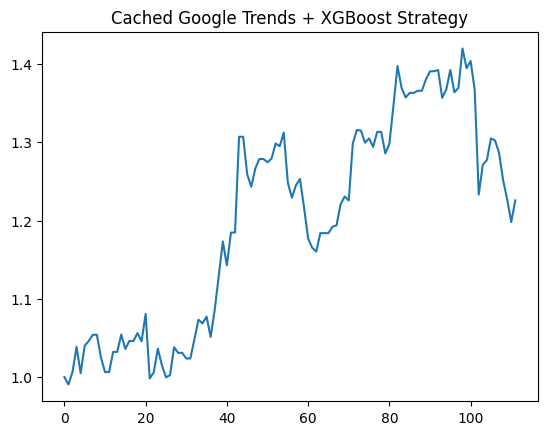

In [118]:
import pandas as pd
import numpy as np
import yfinance as yf
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. LOAD EXISTING CACHE (if it exists)
# --------------------------------------------------

try:
    old = pd.read_csv("google_trends_cache.csv")
    old["date"] = pd.to_datetime(old["date"]).dt.normalize()
except FileNotFoundError:
    old = pd.DataFrame(columns=["date", "ticker", "trend"])

# --------------------------------------------------
# 2. NEW DATA (from your latest run)
#    assumes you already created trend_df
# --------------------------------------------------

new = trend_df.copy()
new["date"] = pd.to_datetime(new["date"]).dt.normalize()

# --------------------------------------------------
# 3. COMBINE + DEDUPLICATE
# --------------------------------------------------

combined = pd.concat([old, new], ignore_index=True)

combined = combined.drop_duplicates(
    subset=["date", "ticker"],
    keep="last"
)

# --------------------------------------------------
# 4. SAVE UPDATED CACHE
# --------------------------------------------------

combined.to_csv("google_trends_cache.csv", index=False)

print("Cache updated. Total rows:", len(combined))

# --------------------------------------------------
# 2. STOCK DATA
# --------------------------------------------------

tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META", "AMD", "TSLA", "LLY"]

prices = yf.download(tickers, start="2026-01-01")["Close"]

returns = prices.pct_change()
momentum_5 = prices.pct_change(5)
momentum_20 = prices.pct_change(20)
vol_20 = returns.rolling(20).std()
ma_20 = prices.rolling(20).mean()
ma_gap = prices / ma_20 - 1
target = returns.shift(-1)

# --------------------------------------------------
# 3. BUILD FEATURE DATASET
# --------------------------------------------------

df_list = []

for t in tickers:
    tmp = pd.DataFrame({
        "return": returns[t],
        "mom_5": momentum_5[t],
        "mom_20": momentum_20[t],
        "vol_20": vol_20[t],
        "ma_gap": ma_gap[t],
        "target": target[t]
    })

    tmp["ticker"] = t
    tmp["date"] = tmp.index

    df_list.append(tmp)

df = pd.concat(df_list).dropna()
df["date"] = pd.to_datetime(df["date"]).dt.normalize()

# --------------------------------------------------
# 4. MERGE CACHED TRENDS
# --------------------------------------------------

df = df.merge(trend_df, on=["date", "ticker"], how="left")

df["trend"] = df["trend"].fillna(0)

# --------------------------------------------------
# 5. FEATURES
# --------------------------------------------------

features = [
    "return",
    "mom_5",
    "mom_20",
    "vol_20",
    "ma_gap",
    "trend"
]

X = df[features]
y = df["target"]

# --------------------------------------------------
# 6. TRAIN / TEST SPLIT
# --------------------------------------------------

split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# --------------------------------------------------
# 7. XGBOOST MODEL
# --------------------------------------------------

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)
print(pred)

# --------------------------------------------------
# 8. TRADING STRATEGY
# --------------------------------------------------
#signal = np.where(pred > 0, 1, -1)
signal = np.where(pred > 0.002, 1,
         np.where(pred < -0.002, -1, 0))
print(signal)
strategy_returns = signal * y_test.values

equity = (1 + strategy_returns).cumprod()
print(equity)

# --------------------------------------------------
# 9. EVALUATION
# --------------------------------------------------

corr = np.corrcoef(pred, y_test)[0, 1]
print("Prediction correlation:", corr)

plt.figure()
plt.plot(equity)
plt.title("Cached Google Trends + XGBoost Strategy")
plt.show()

In [119]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# 1. DEFINE FEATURE COLUMNS (must match training)
# --------------------------------------------------

feature_cols = [
    "return",
    "mom_5",
    "mom_20",
    "vol_20",
    "ma_gap",
    "trend"
]

# --------------------------------------------------
# 2. GET MOST RECENT DATA FOR EACH STOCK
# --------------------------------------------------

latest = df.sort_values("date").groupby("ticker").tail(1).copy()

# --------------------------------------------------
# 3. BUILD INPUT FEATURES FOR PREDICTION
# --------------------------------------------------

X_live = latest[feature_cols]

# --------------------------------------------------
# 4. PREDICT NEXT-DAY RETURNS
# --------------------------------------------------

latest["predicted_return_tomorrow"] = model.predict(X_live)

# --------------------------------------------------
# 5. CONVERT TO TRADING SIGNAL
#    (long if positive, short if negative)
# --------------------------------------------------

latest["position"] = np.where(latest["predicted_return_tomorrow"] > 0.002, 1,
         np.where(latest["predicted_return_tomorrow"] < -0.002, -1, 0))


# --------------------------------------------------
# 6. OPTIONAL: CONFIDENCE-BASED SIZING
# --------------------------------------------------

latest["position_scaled"] = latest["predicted_return_tomorrow"] / (
    latest["vol_20"].replace(0, np.nan)
)

latest["position_scaled"] = latest["position_scaled"].fillna(0)

# --------------------------------------------------
# 7. OUTPUT RESULTS
# --------------------------------------------------

print("\n📊 TOMORROW PREDICTIONS\n")
print(latest[[
    "ticker",
    "predicted_return_tomorrow",
    "position",
    "position_scaled"
]])

print(df["date"].max())


📊 TOMORROW PREDICTIONS

    ticker  predicted_return_tomorrow  position  position_scaled
279  GOOGL                   0.021258         1         0.833708
419    AMD                   0.008099         1         0.129707
349   META                   0.007681         1         0.329905
209   AMZN                   0.006202         1         0.496887
139   MSFT                  -0.003989        -1        -0.193266
69    AAPL                   0.007824         1         0.477548
489   TSLA                   0.018846         1         0.695904
559    LLY                   0.002180         1         0.073361
2026-05-12 00:00:00
